# Notebook 02 — Segmentación con SAM

**Objetivo**: usar SAM (Segment Anything Model) para detectar y recortar filetes automáticamente.

Flujo:
1. Cargar SAM
2. Limpiar imagen (pipeline del notebook 01)
3. SAM detecta máscaras automáticamente
4. Filtrar las máscaras que corresponden a filetes
5. Guardar imágenes limpias para anotar en Label Studio
6. Verificar anotaciones COCO exportadas de Label Studio

## 1. Imports y carga de SAM

In [8]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Rutas
DATA_ROOT   = Path(r'..\images\roscas')
MODELO_PATH = Path(r'..\models\sam_vit_b.pth')
OUTPUT_DIR  = Path(r'..\images\roscas_limpias')
ANNOT_PATH  = Path(r'..\annotations\RB01_coco.json')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

sam = sam_model_registry['vit_b'](checkpoint=str(MODELO_PATH))
sam.to(device)
mask_generator = SamAutomaticMaskGenerator(sam)
print('SAM cargado')

Dispositivo: cuda
SAM cargado


## 2. Función de limpieza (del notebook 01)

In [9]:
def limpiar_imagen(ruta: str) -> np.ndarray:
    """
    Limpia una imagen de rosca eliminando artefactos, cabezal y ruido.
    Devuelve mascara binaria recortada lista para el modelo.
    """
    img = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
    h, w = img.shape
    mitad = h // 2
    img[img > 240] = 255
    _, binaria = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    binaria = cv2.bitwise_not(binaria)
    rosca_blanca = cv2.bitwise_not(binaria)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(rosca_blanca)
    areas = stats[1:, cv2.CC_STAT_AREA]
    mayor = np.argmax(areas) + 1
    mascara = (labels == mayor).astype(np.uint8) * 255
    mascara_inferior = mascara[mitad:, :]
    span_columnas = np.zeros(w)
    for col in range(w):
        pixeles = np.where(mascara_inferior[:, col] > 0)[0]
        if len(pixeles) > 0:
            span_columnas[col] = (pixeles[-1] - pixeles[0]) / (h // 2)
    ultimo_valle = w
    for col in range(w - 1, -1, -1):
        if span_columnas[col] < 0.7:
            ultimo_valle = col
            break
    mascara = mascara[:, :ultimo_valle]
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mascara)
    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        mayor = np.argmax(areas) + 1
        mascara = (labels == mayor).astype(np.uint8) * 255
    filas = np.where(mascara.any(axis=1))[0]
    if len(filas) == 0:
        return mascara
    fila_top = filas[0]
    fila_bot = filas[-1]
    margen = 20
    return mascara[max(0, fila_top - margen):min(h, fila_bot + margen), :]

## 3. Guardar imágenes limpias para Label Studio

In [10]:
for clase in ['Buenas', 'Malas']:
    for carpeta_rosca in sorted((DATA_ROOT / clase).iterdir()):
        output = OUTPUT_DIR / clase / carpeta_rosca.name
        output.mkdir(parents=True, exist_ok=True)
        for ruta in sorted(carpeta_rosca.glob('*.jpg')):
            limpia = limpiar_imagen(str(ruta))
            cv2.imwrite(str(output / ruta.name), limpia)
        print(f'Guardada: {clase}/{carpeta_rosca.name}')

print('\nListo!')

Guardada: Buenas/RB01
Guardada: Buenas/RB02
Guardada: Buenas/RB03
Guardada: Buenas/RB04
Guardada: Buenas/RB05
Guardada: Buenas/RB06
Guardada: Buenas/RB07
Guardada: Buenas/RB08
Guardada: Buenas/RB09
Guardada: Buenas/RB10
Guardada: Buenas/RB11
Guardada: Malas/RM01
Guardada: Malas/RM02
Guardada: Malas/RM03
Guardada: Malas/RM04
Guardada: Malas/RM05
Guardada: Malas/RM06
Guardada: Malas/RM07
Guardada: Malas/RM08
Guardada: Malas/RM09
Guardada: Malas/RM10
Guardada: Malas/RM11

Listo!


## 4. Probar SAM sobre una imagen limpia

Segmentando...
Mascaras detectadas: 7


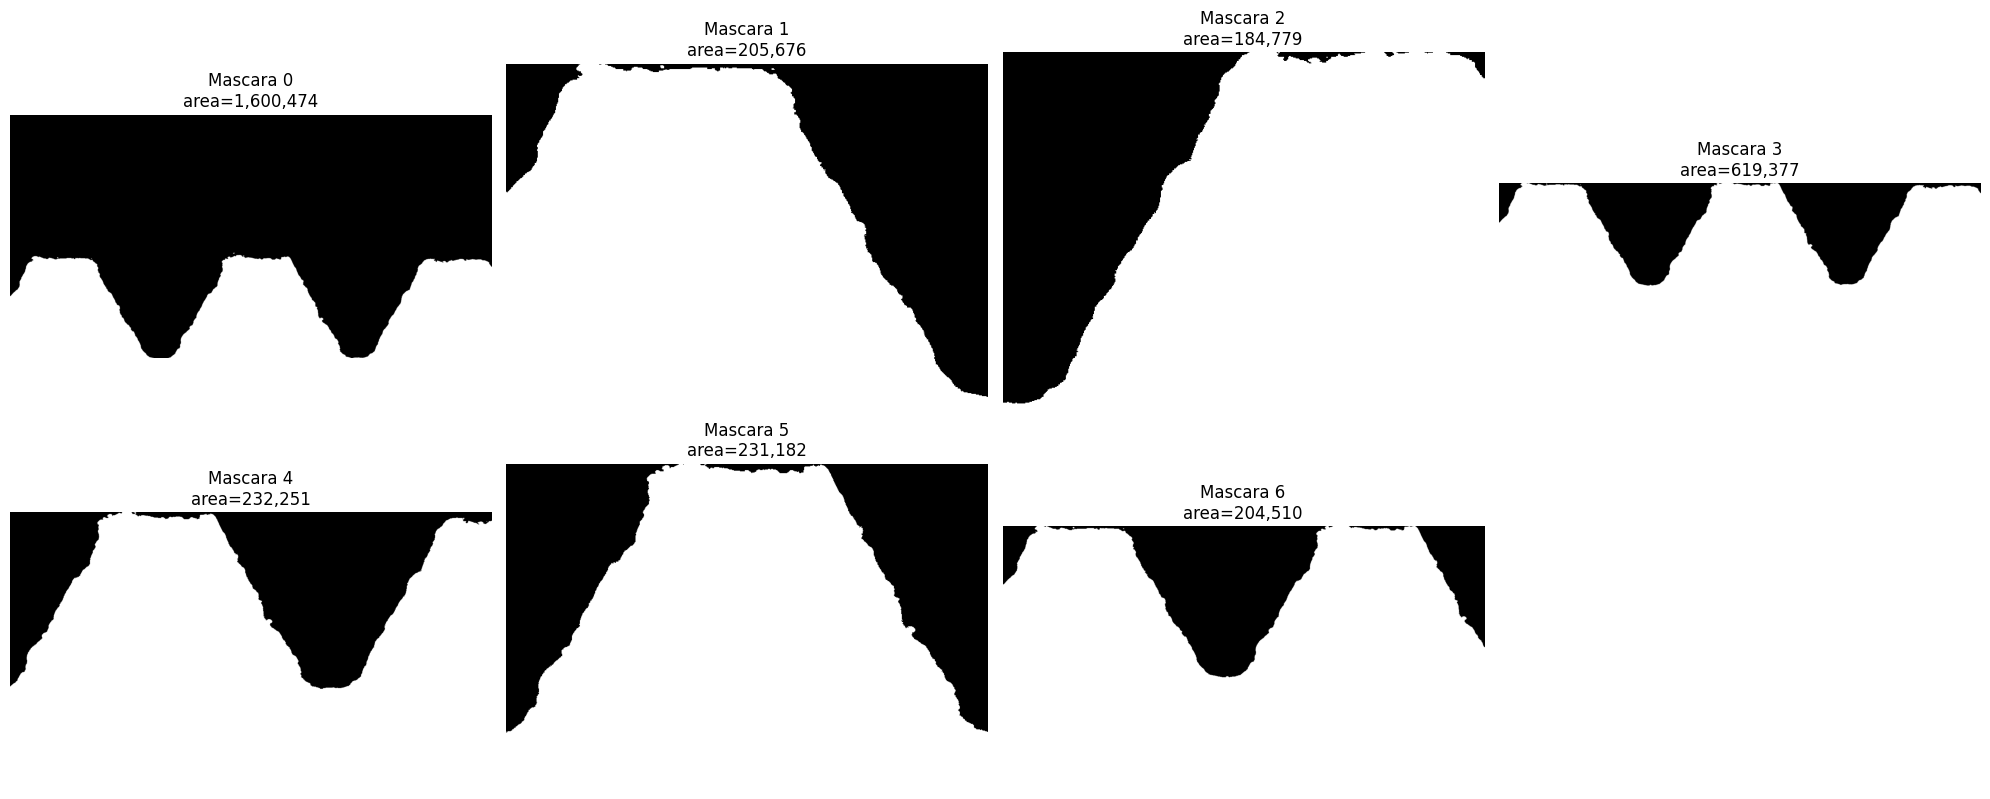

In [11]:
ruta = DATA_ROOT / 'Buenas' / 'RB01' / 'Imagen_000506.jpg'
resultado = limpiar_imagen(str(ruta))

# Invertir y convertir a RGB para SAM
img_sam = cv2.bitwise_not(resultado)
img_rgb = cv2.cvtColor(img_sam, cv2.COLOR_GRAY2RGB)

print('Segmentando...')
mascaras = mask_generator.generate(img_rgb)
print(f'Mascaras detectadas: {len(mascaras)}')

# Visualizar todas las mascaras
n = len(mascaras)
cols = min(n, 4)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = np.array(axes).flatten()

for i, m in enumerate(mascaras):
    x, y, w_b, h_b = m['bbox']
    recorte = img_rgb[y:y+h_b, x:x+w_b]
    axes[i].imshow(recorte)
    axes[i].set_title(f'Mascara {i}\narea={m["area"]:,}')
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 5. Verificar anotaciones COCO de Label Studio

In [12]:
import json

with open(ANNOT_PATH, 'r') as f:
    coco = json.load(f)

print(f'Imagenes:     {len(coco["images"])}')
print(f'Anotaciones:  {len(coco["annotations"])}')
print(f'Categorias:   {coco["categories"]}')
print(f'Media por imagen: {len(coco["annotations"])/len(coco["images"]):.1f}')

Imagenes:     12
Anotaciones:  57
Categorias:   [{'id': 0, 'name': 'Filete'}, {'id': 1, 'name': 'Paso'}]
Media por imagen: 4.8


In [13]:
# Verificar cuántas imágenes hay por carpeta antes de procesar
for clase in ["Buenas", "Malas"]:
    clase_dir = DATA_ROOT / clase
    for carpeta_rosca in sorted(clase_dir.iterdir()):
        imgs = list(carpeta_rosca.glob("*.jpg"))
        ya_procesadas = (
            list((OUTPUT_DIR / clase / carpeta_rosca.name).glob("*.jpg"))
            if (OUTPUT_DIR / clase / carpeta_rosca.name).exists()
            else []
        )
        print(
            f"{clase}/{carpeta_rosca.name}: {len(imgs)} imgs origen | {len(ya_procesadas)} ya procesadas"
        )

Buenas/RB01: 12 imgs origen | 12 ya procesadas
Buenas/RB02: 11 imgs origen | 11 ya procesadas
Buenas/RB03: 11 imgs origen | 11 ya procesadas
Buenas/RB04: 12 imgs origen | 12 ya procesadas
Buenas/RB05: 12 imgs origen | 12 ya procesadas
Buenas/RB06: 12 imgs origen | 12 ya procesadas
Buenas/RB07: 12 imgs origen | 12 ya procesadas
Buenas/RB08: 12 imgs origen | 12 ya procesadas
Buenas/RB09: 12 imgs origen | 12 ya procesadas
Buenas/RB10: 12 imgs origen | 12 ya procesadas
Buenas/RB11: 12 imgs origen | 12 ya procesadas
Malas/RM01: 12 imgs origen | 12 ya procesadas
Malas/RM02: 12 imgs origen | 12 ya procesadas
Malas/RM03: 12 imgs origen | 12 ya procesadas
Malas/RM04: 12 imgs origen | 12 ya procesadas
Malas/RM05: 12 imgs origen | 12 ya procesadas
Malas/RM06: 12 imgs origen | 12 ya procesadas
Malas/RM07: 12 imgs origen | 12 ya procesadas
Malas/RM08: 12 imgs origen | 12 ya procesadas
Malas/RM09: 12 imgs origen | 12 ya procesadas
Malas/RM10: 12 imgs origen | 12 ya procesadas
Malas/RM11: 12 imgs ori